# Report figures & tables — MS&E 242 final (Christy's sections)

Generates every plot, graph, and table called for in the report writing plan and saves them to
`results/report_plot/`. Deliverables:

| # | Plan section | Output |
|---|---|---|
| 1 | §1 Data & preprocessing | `table1_raw_data_inventory` — 12-market raw-data inventory |
| 2 | §4 Hyperparameter selection | `fig_loss_curve` — train/val loss curve (seed-42 winner) |
| 3 | §5.2 Performance | `fig_perf_*` — one graph per model, all 3 metrics by horizon |
| 4 | §5.3 Performance | `table_c_in_vs_out` — in-sample vs out-of-sample, all models vs benchmarks |
| 5 | §5.4 Market-group | `fig_market_group_means` + `table_group_means` + `table_spearman` |

**Conventions.** All metric values are formatted to **4 decimal places**. Sources are read directly from
`results/`; the only embedded constants are the in-sample Ridge per-horizon numbers from
`scripts/ridge_in_sample.py` (which reproduces the logged out-of-sample Ridge benchmark exactly).

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ---- paths -------------------------------------------------------------------
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RESULTS = ROOT / "results"
OUTDIR = RESULTS / "report_plot"
OUTDIR.mkdir(parents=True, exist_ok=True)
print("Output dir:", OUTDIR)

HORIZONS = [1, 2, 3, 5, 10]
HK = [str(h) for h in HORIZONS]

# ---- consistent style --------------------------------------------------------
mpl.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 200,
    "savefig.bbox": "tight",
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "grid.linestyle": "--",
    "legend.frameon": False,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
})

# Series palette (used across every performance figure for consistency).
C_IN     = "#3B6FB6"   # in-sample (train)
C_TEST   = "#D1612A"   # out-of-sample (test)
C_RIDGE  = "#8C8C8C"   # Ridge linear benchmark
C_REF    = "#444444"   # naive / baseline reference line
# Volatility-group palette (matches the plan / viz_09).
GROUP_COLORS = {"Low": "#4C9F70", "Mid": "#E1A33A", "High": "#C5413B"}

METRICS = [
    ("r2_oos", "Out-of-sample $R^2$", 0.0),                 # (key, label, naive ref)
    ("directional_accuracy", "Directional accuracy", 0.5),
    ("sharpe", "Annualized Sharpe", 0.0),
]

def fmt4(x):
    """Format a metric to 4 decimal places (handles NaN / None / dash)."""
    if x is None or (isinstance(x, float) and np.isnan(x)):
        return "—"
    return f"{x:.4f}"

def per_h(block, key):
    """Pull a per-horizon list from a metrics block."""
    return [float(block[key][h]) for h in HK]

def save_table(df, name, title=None, col_width=None):
    """Save a DataFrame as a CSV and a rendered PNG table with a title."""
    csv_path = OUTDIR / f"{name}.csv"
    df.to_csv(csv_path, index=False)
    n_rows, n_cols = df.shape
    fig_w = min(2.0 + 1.45 * n_cols, 20)
    fig_h = 0.55 * (n_rows + 1) + (0.6 if title else 0.2)
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    ax.axis("off")
    if title:
        ax.set_title(title, pad=12)
    tbl = ax.table(cellText=df.values, colLabels=df.columns,
                   cellLoc="center", loc="center")
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(10)
    tbl.scale(1, 1.45)
    for (r, c), cell in tbl.get_celld().items():
        cell.set_edgecolor("#DDDDDD")
        if r == 0:
            cell.set_facecolor("#2F3B52")
            cell.set_text_props(color="white", fontweight="bold")
        elif r % 2 == 0:
            cell.set_facecolor("#F4F6F9")
    png_path = OUTDIR / f"{name}.png"
    fig.savefig(png_path)
    plt.show()
    print("saved:", csv_path.name, "+", png_path.name)
    return df

print("Setup complete.")

Output dir: /Users/christy/Desktop/3/26Spring_MS&E242/MS&E242_final/results/report_plot
Setup complete.


## Load data sources

In [2]:
# Best CNN-LSTM run (seed 42) — authoritative per-horizon metrics + training history.
CNN_RUN = RESULTS / "runs" / "cnn_lstm_20260610T025536_9748420000.json"
cnn = json.loads(CNN_RUN.read_text())

# Best LSTM / LSTM-MLP runs (Jing's models) from the experiment log.
EXP = [json.loads(l) for l in (RESULTS / "experiments.jsonl").read_text().splitlines() if l.strip()]
def latest(tag):
    hits = [r for r in EXP if str(r.get("tag")) == tag]
    if not hits:
        raise KeyError(f"tag {tag!r} not found in experiments.jsonl")
    return hits[-1]
lstm     = latest("ls2-stride5-nl1-h128")
lstm_mlp = latest("ml2-h128-mlp1x64")

# One record per model: (display name, n_params, metrics dict with in/out/ridge blocks).
MODELS = {
    "CNN-LSTM": {"params": cnn["n_params"],     "m": cnn["metrics"]},
    "LSTM":     {"params": lstm["n_params"],     "m": lstm["metrics"]},
    "LSTM-MLP": {"params": lstm_mlp["n_params"], "m": lstm_mlp["metrics"]},
}
for name, d in MODELS.items():
    mm = d["m"]
    print(f"{name:9s} params={d['params']:>8,}  "
          f"test R2={mm['out_of_sample']['r2_oos_mean']:+.4f}  "
          f"DirAcc={mm['out_of_sample']['directional_accuracy_mean']:.4f}  "
          f"Sharpe={mm['out_of_sample']['sharpe_mean']:.4f}")

# In-sample Ridge benchmark per horizon — from scripts/ridge_in_sample.py
# (the run logs only stored the out-of-sample Ridge block, so these are computed
#  by re-fitting the identical Ridge on the train windows and scoring on train).
RIDGE_IN = {
    "r2_oos":               [-0.0436, -0.0349, -0.0599, -0.0527, -0.0508],
    "directional_accuracy": [ 0.6240,  0.5480,  0.5560,  0.5450,  0.5230],
    "sharpe":               [ 0.4180,  0.3310,  0.3570,  0.3650,  0.3380],
}

# Liquidity + grouping for the §1 inventory table.
findings = json.loads((RESULTS / "data_findings.json").read_text())
groups   = json.loads((RESULTS / "market_groups.json").read_text())
liq_by_label = {row["label"]: row for row in findings["liquidity"]}
print("\nLoaded:", len(groups["markets"]), "markets,", len(EXP), "experiment records.")

CNN-LSTM  params= 125,125  test R2=+0.0007  DirAcc=0.6134  Sharpe=0.5514
LSTM      params=  77,445  test R2=-0.0005  DirAcc=0.6085  Sharpe=0.3851
LSTM-MLP  params=  85,381  test R2=-0.0017  DirAcc=0.5969  Sharpe=0.4785

Loaded: 12 markets, 68 experiment records.


## §1 — Raw-data inventory of the 12 markets

Merges `market_groups.json` (snapshot count, volatility group, realized vol full/test) with the
liquidity metrics in `data_findings.json` (median spread, tight-spread fraction, median mid).
Ordered by volatility group (Low → Mid → High), then by snapshot count.

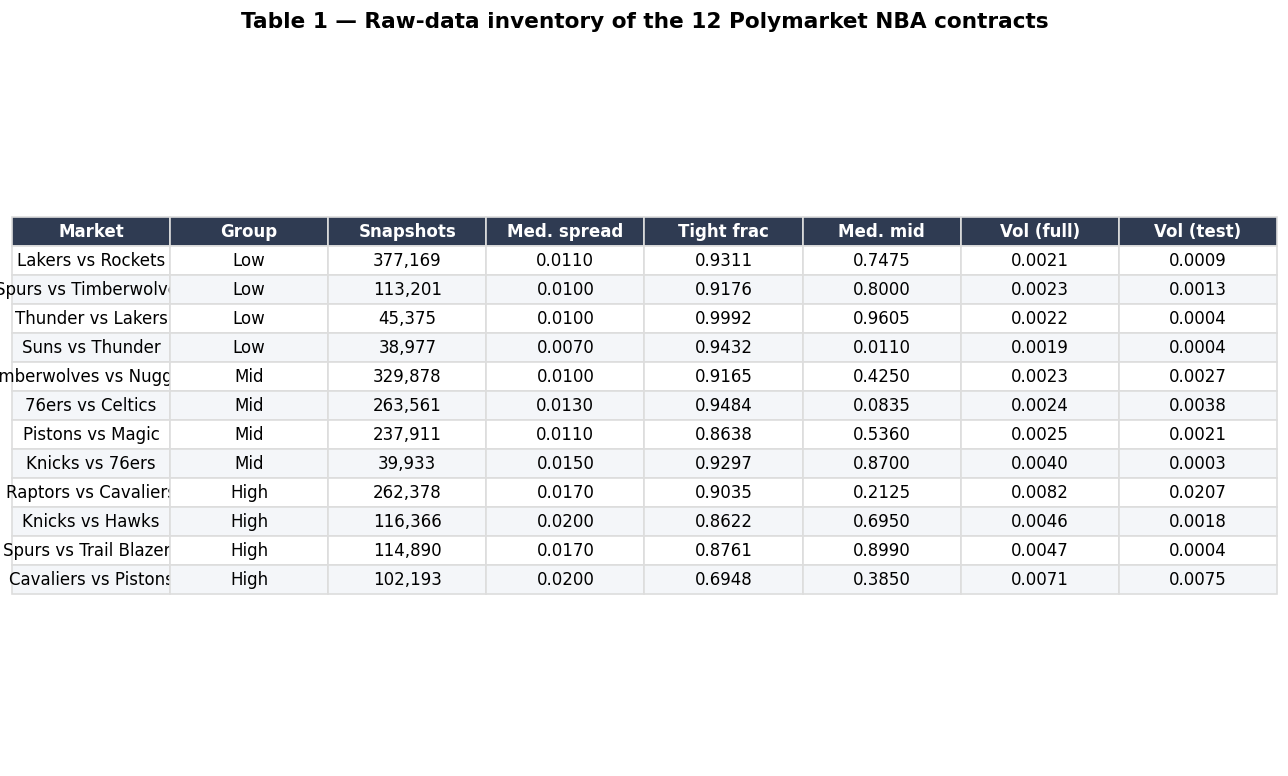

saved: table1_raw_data_inventory.csv + table1_raw_data_inventory.png


,Market,Group,Snapshots,Med. spread,Tight frac,Med. mid,Vol (full),Vol (test)
0,Lakers vs Rockets,Low,"377,169",0.0110,0.9311,0.7475,0.0021,0.0009
1,Spurs vs Timberwolves,Low,"113,201",0.0100,0.9176,0.8000,0.0023,0.0013
2,Thunder vs Lakers,Low,"45,375",0.0100,0.9992,0.9605,0.0022,0.0004
3,Suns vs Thunder,Low,"38,977",0.0070,0.9432,0.0110,0.0019,0.0004
4,Timberwolves vs Nuggets,Mid,"329,878",0.0100,0.9165,0.4250,0.0023,0.0027
5,76ers vs Celtics,Mid,"263,561",0.0130,0.9484,0.0835,0.0024,0.0038
6,Pistons vs Magic,Mid,"237,911",0.0110,0.8638,0.5360,0.0025,0.0021
7,Knicks vs 76ers,Mid,"39,933",0.0150,0.9297,0.8700,0.0040,0.0003
8,Raptors vs Cavaliers,High,"262,378",0.0170,0.9035,0.2125,0.0082,0.0207
9,Knicks vs Hawks,High,"116,366",0.0200,0.8622,0.6950,0.0046,0.0018


In [3]:
GROUP_ORDER = {"Low": 0, "Mid": 1, "High": 2}
rows = []
for mk in groups["markets"]:
    label = mk["key"].split("__")[0]
    liq = liq_by_label[label]
    rows.append({
        "Market": label,
        "Group": mk["group"],
        "Snapshots": mk["n"],
        "Med. spread": liq["med_spread"],
        "Tight frac": liq["tight_frac"],
        "Med. mid": liq["med_mid"],
        "Vol (full)": mk["realized_vol"],
        "Vol (test)": mk["realized_vol_test"],
    })
inv = pd.DataFrame(rows)
inv = inv.sort_values(by=["Group", "Snapshots"],
                      key=lambda s: s.map(GROUP_ORDER) if s.name == "Group" else -s,
                      ).reset_index(drop=True)

inv_disp = inv.copy()
inv_disp["Snapshots"]   = inv_disp["Snapshots"].map(lambda v: f"{v:,}")
for col in ["Med. spread", "Tight frac", "Med. mid", "Vol (full)", "Vol (test)"]:
    inv_disp[col] = inv_disp[col].map(fmt4)

save_table(inv_disp, "table1_raw_data_inventory",
           title="Table 1 — Raw-data inventory of the 12 Polymarket NBA contracts")

## §4 — Train / validation loss curve (winning seed-42 run)

Standardized-MSE loss per epoch from the run's `training.history`. The dashed line marks the
mean-predictor baseline (standardized MSE ≈ 1.0); the vertical marker is the best-validation epoch
(weights restored there), with the early-stop epoch annotated.

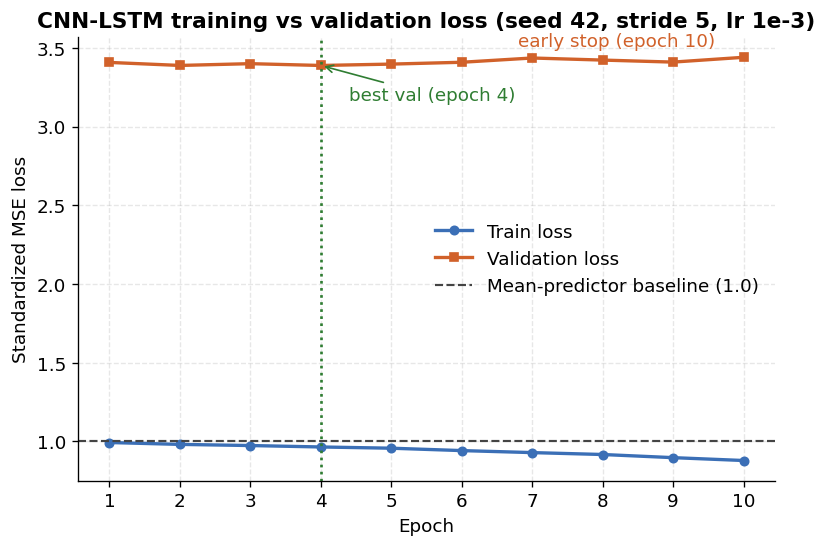

saved: fig_loss_curve.png  | best epoch = 4


In [4]:
hist = cnn["training"]["history"]
train_loss = hist["train_loss"]
val_loss = hist["val_loss"]
epochs = np.arange(1, len(train_loss) + 1)
best_ep = int(np.argmin(val_loss)) + 1
stop_ep = int(epochs[-1])

fig, ax = plt.subplots(figsize=(7.5, 4.8))
ax.plot(epochs, train_loss, "-o", color=C_IN, label="Train loss", lw=2, ms=5)
ax.plot(epochs, val_loss, "-s", color=C_TEST, label="Validation loss", lw=2, ms=5)
ax.axhline(1.0, ls="--", color=C_REF, lw=1.3,
           label="Mean-predictor baseline (1.0)")
ax.axvline(best_ep, ls=":", color="#2F7D32", lw=1.6)
ax.annotate(f"best val (epoch {best_ep})",
            xy=(best_ep, val_loss[best_ep - 1]),
            xytext=(best_ep + 0.4, max(val_loss) * 0.92),
            color="#2F7D32",
            arrowprops=dict(arrowstyle="->", color="#2F7D32"))
ax.annotate(f"early stop (epoch {stop_ep})",
            xy=(stop_ep, val_loss[-1]),
            xytext=(stop_ep - 3.2, val_loss[-1] + 0.07),
            color=C_TEST)
ax.set_xlabel("Epoch")
ax.set_ylabel("Standardized MSE loss")
ax.set_title("CNN-LSTM training vs validation loss (seed 42, stride 5, lr 1e-3)")
ax.set_xticks(epochs)
ax.legend(loc="center right")
fig.savefig(OUTDIR / "fig_loss_curve.png")
plt.show()
print("saved: fig_loss_curve.png  | best epoch =", best_ep)

## §5.2 — Per-model performance by horizon (one graph per model, all metrics)

One figure per model (CNN-LSTM, LSTM, LSTM-MLP), each with three panels (R²_OS, DirAcc, Sharpe).
Within a panel, the x-axis is the horizon and the three bars per horizon are the model's **in-sample**,
its **TEST (seed 42)**, and its own **Ridge (test, OOS)** benchmark. Naive reference lines at R²=0 /
DirAcc=0.5 / Sharpe=0. Y-axis ranges are shared across the three model figures so they read as directly
comparable.

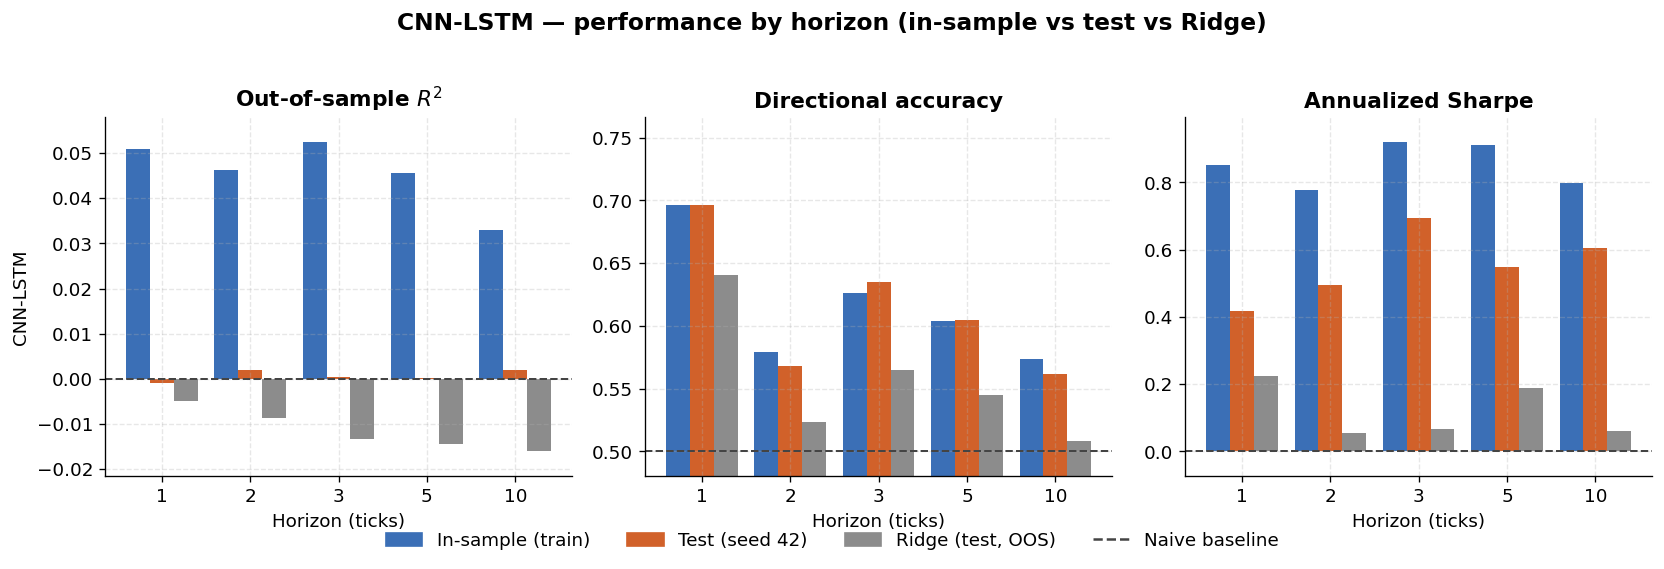

saved: fig_perf_cnn_lstm.png


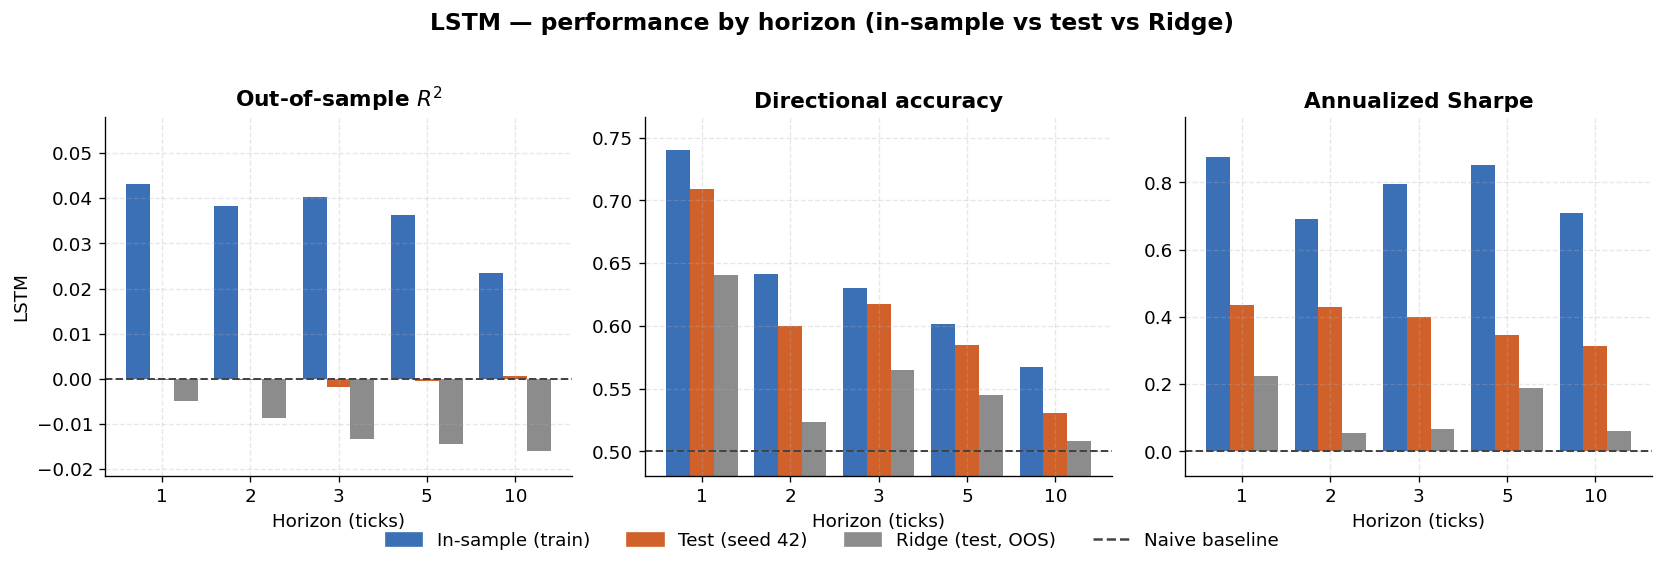

saved: fig_perf_lstm.png


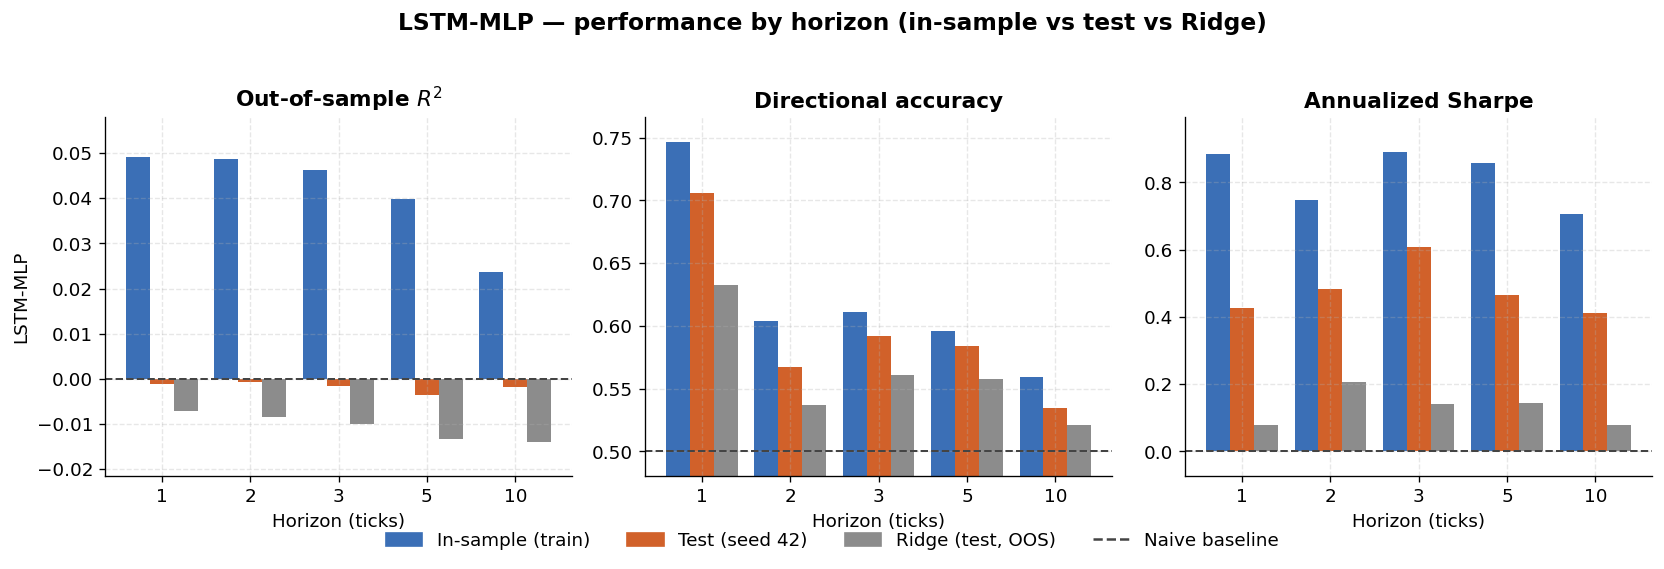

saved: fig_perf_lstm_mlp.png


In [5]:
SLUG = {"CNN-LSTM": "cnn_lstm", "LSTM": "lstm", "LSTM-MLP": "lstm_mlp"}

# Shared y-limits per metric, computed across every model/series so the 3 figures are comparable.
ylims = {}
for key, _, ref in METRICS:
    vals = [ref]
    for d in MODELS.values():
        m = d["m"]
        vals += per_h(m["in_sample"], key) + per_h(m["out_of_sample"], key) + per_h(m["linear_benchmark_oos"], key)
    lo, hi = min(vals), max(vals)
    pad = 0.08 * (hi - lo if hi > lo else 1.0)
    ylims[key] = (lo - pad, hi + pad)

def make_perf_figure(name, d):
    m = d["m"]
    x = np.arange(len(HORIZONS))
    w = 0.27
    fig, axes = plt.subplots(1, 3, figsize=(14, 4.4))
    for ax, (key, label, ref) in zip(axes, METRICS):
        ins   = per_h(m["in_sample"], key)
        test  = per_h(m["out_of_sample"], key)
        ridge = per_h(m["linear_benchmark_oos"], key)
        ax.bar(x - w, ins,   w, color=C_IN,    label="In-sample (train)")
        ax.bar(x,     test,  w, color=C_TEST,  label="Test (seed 42)")
        ax.bar(x + w, ridge, w, color=C_RIDGE, label="Ridge (test, OOS)")
        ax.axhline(ref, ls="--", color=C_REF, lw=1.2)
        ax.set_title(label)
        ax.set_xlabel("Horizon (ticks)")
        ax.set_xticks(x)
        ax.set_xticklabels(HK)
        ax.set_ylim(*ylims[key])
    axes[0].set_ylabel(name)
    handles = [
        mpl.patches.Patch(color=C_IN, label="In-sample (train)"),
        mpl.patches.Patch(color=C_TEST, label="Test (seed 42)"),
        mpl.patches.Patch(color=C_RIDGE, label="Ridge (test, OOS)"),
        Line2D([0], [0], ls="--", color=C_REF, label="Naive baseline"),
    ]
    fig.legend(handles=handles, loc="lower center", ncol=4, bbox_to_anchor=(0.5, -0.03))
    fig.suptitle(f"{name} — performance by horizon (in-sample vs test vs Ridge)",
                 fontsize=14, fontweight="bold", y=1.02)
    fig.tight_layout()
    path = OUTDIR / f"fig_perf_{SLUG[name]}.png"
    fig.savefig(path)
    plt.show()
    print("saved:", path.name)

for name, d in MODELS.items():
    make_perf_figure(name, d)

## §5.3 — Table C: in-sample vs out-of-sample (mean over horizons)

Horizon-means for every model and the two benchmarks. Ridge in-sample is computed by
`scripts/ridge_in_sample.py`; its test column is the canonical logged Ridge benchmark. Naive is shown
as the definitional baseline (R²=0, DirAcc=0.5, Sharpe=0).

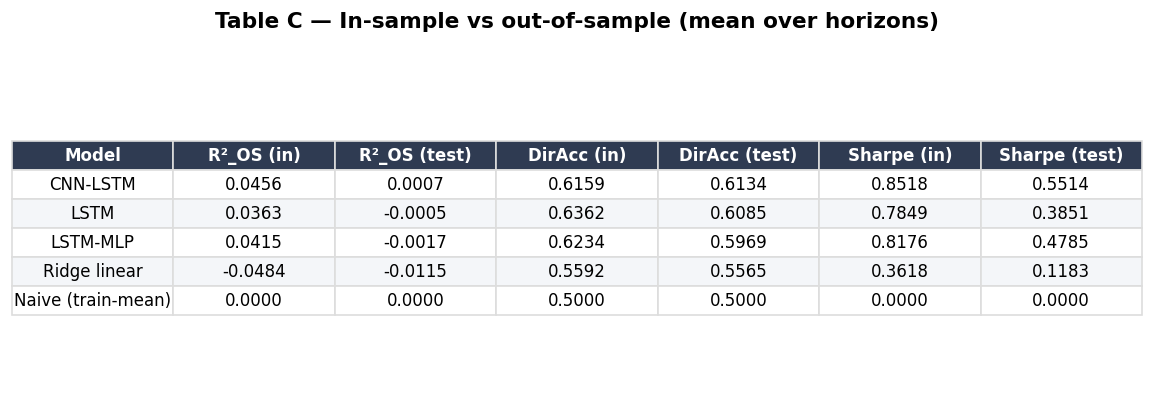

saved: table_c_in_vs_out.csv + table_c_in_vs_out.png


,Model,R²_OS (in),R²_OS (test),DirAcc (in),DirAcc (test),Sharpe (in),Sharpe (test)
0,CNN-LSTM,0.0456,0.0007,0.6159,0.6134,0.8518,0.5514
1,LSTM,0.0363,-0.0005,0.6362,0.6085,0.7849,0.3851
2,LSTM-MLP,0.0415,-0.0017,0.6234,0.5969,0.8176,0.4785
3,Ridge linear,-0.0484,-0.0115,0.5592,0.5565,0.3618,0.1183
4,Naive (train-mean),0.0000,0.0000,0.5000,0.5000,0.0000,0.0000


In [6]:
def block_means(block):
    return (block["r2_oos_mean"], block["directional_accuracy_mean"], block["sharpe_mean"])

rows = []
for name, d in MODELS.items():
    r2_i, da_i, sh_i = block_means(d["m"]["in_sample"])
    r2_t, da_t, sh_t = block_means(d["m"]["out_of_sample"])
    rows.append([name, r2_i, r2_t, da_i, da_t, sh_i, sh_t])

# Ridge: in-sample from re-fit script; test = canonical logged benchmark (CNN-LSTM run).
ridge_test = block_means(cnn["metrics"]["linear_benchmark_oos"])
ridge_in = (float(np.mean(RIDGE_IN["r2_oos"])),
            float(np.mean(RIDGE_IN["directional_accuracy"])),
            float(np.mean(RIDGE_IN["sharpe"])))
rows.append(["Ridge linear", ridge_in[0], ridge_test[0],
             ridge_in[1], ridge_test[1], ridge_in[2], ridge_test[2]])

# Naive (train-mean): definitional baseline.
rows.append(["Naive (train-mean)", 0.0, 0.0, 0.5, 0.5, 0.0, 0.0])

cols = ["Model", "R²_OS (in)", "R²_OS (test)",
        "DirAcc (in)", "DirAcc (test)", "Sharpe (in)", "Sharpe (test)"]
tablec = pd.DataFrame(rows, columns=cols)

tablec_disp = tablec.copy()
for col in cols[1:]:
    tablec_disp[col] = tablec_disp[col].map(fmt4)
save_table(tablec_disp, "table_c_in_vs_out",
           title="Table C — In-sample vs out-of-sample (mean over horizons)")

## §5.4 — Market-group analysis (volatility robustness sub-experiment)

Per-market test metrics (seed 42) from `MARKET_GROUP_ANALYSIS.md`, combined with the realized-vol values
in `market_groups.json`. We (a) plot group means (Low/Mid/High) per metric, (b) tabulate simple and
window-weighted group means, and (c) run a Spearman rank correlation (n=12) of volatility vs each metric
against both full-series and test-segment vol.

In [7]:
from scipy.stats import spearmanr

# Per-market TEST metrics (seed 42) from results/MARKET_GROUP_ANALYSIS.md: label -> (R2_OS, DirAcc, Sharpe, n_win)
# label -> (R2_OS, DirAcc, Sharpe, n_win, vol_test). vol_test here is the test-window return
# volatility the analysis correlates on (std of test-window h=1 targets), which differs from
# market_groups.json's realized_vol_test (std of mid-diffs); both come straight from the MD.
PERMARKET = {
    "Suns vs Thunder":        (-0.0848, 0.5814, 0.3000,  583, 0.000498),
    "Lakers vs Rockets":      (-0.1754, 0.5892, 0.7438, 5656, 0.000894),
    "Thunder vs Lakers":      (-0.9249, 0.6580, 3.0933,  680, 0.000332),
    "Spurs vs Timberwolves":  ( 0.0185, 0.6227, 0.9805, 1697, 0.001288),
    "Timberwolves vs Nuggets":( 0.0425, 0.6947, 1.6064, 4947, 0.003103),
    "76ers vs Celtics":       ( 0.0104, 0.5716, 1.0600, 3953, 0.003909),
    "Pistons vs Magic":       (-0.1434, 0.6886, 1.4637, 3568, 0.001501),
    "Knicks vs 76ers":        (-0.4988, 0.6278, 1.1921,  598, 0.000295),
    "Knicks vs Hawks":        (-0.0021, 0.5664, 0.3644, 1744, 0.000951),
    "Spurs vs Trail Blazers": (-0.3885, 0.5920, 0.5059, 1723, 0.000467),
    "Cavaliers vs Pistons":   ( 0.0077, 0.6048, 1.1554, 1532, 0.010027),
    "Raptors vs Cavaliers":   ( 0.0023, 0.6321, 0.9179, 3934, 0.024527),
}
MET3 = ["r2_oos", "directional_accuracy", "sharpe"]
mg = []
for mk in groups["markets"]:
    label = mk["key"].split("__")[0]
    r2, da, sh, n, vt = PERMARKET[label]
    mg.append({"Market": label, "Group": mk["group"], "n_win": n,
               "vol_full": mk["realized_vol"], "vol_test": vt,
               "r2_oos": r2, "directional_accuracy": da, "sharpe": sh})
mg = pd.DataFrame(mg)
GROUPS = ["Low", "Mid", "High"]

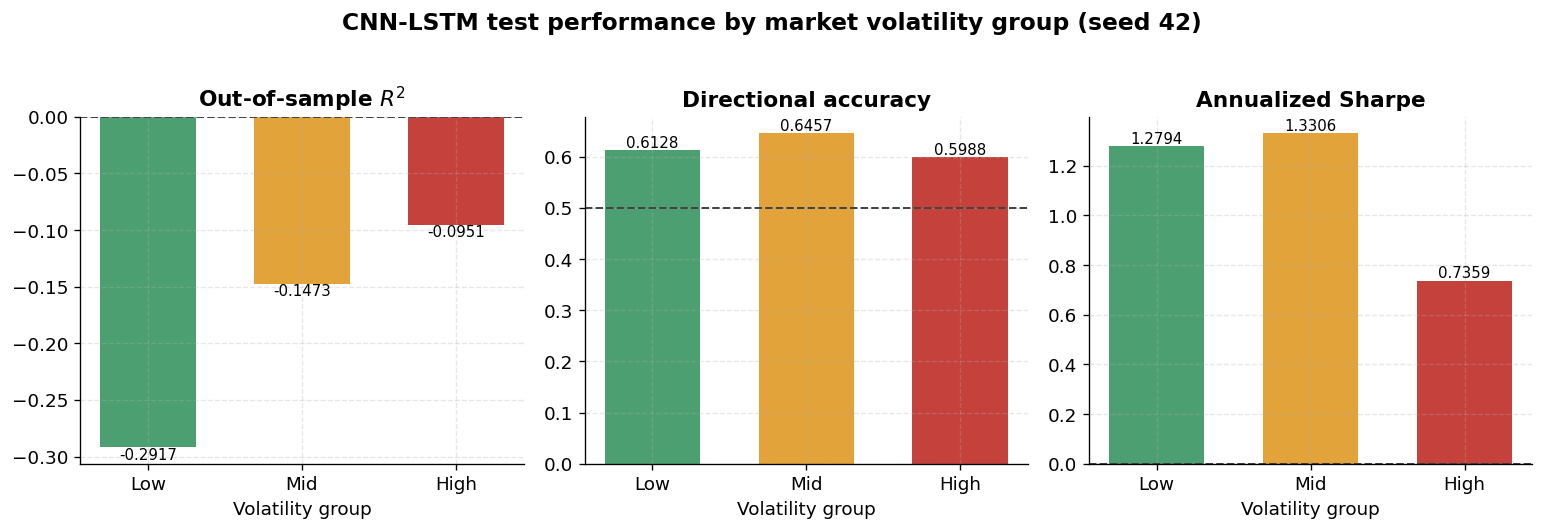

saved: fig_market_group_means.png


In [8]:
# --- Figure: group means per metric ---
means = mg.groupby("Group")[MET3].mean().reindex(GROUPS)
fig, axes = plt.subplots(1, 3, figsize=(13, 4.3))
for ax, (key, label, ref) in zip(axes, METRICS):
    vals = means[key].values
    ax.bar(GROUPS, vals, color=[GROUP_COLORS[g] for g in GROUPS], width=0.62)
    ax.axhline(ref, ls="--", color=C_REF, lw=1.2)
    ax.set_title(label)
    ax.set_xlabel("Volatility group")
    for i, v in enumerate(vals):
        ax.text(i, v, fmt4(v), ha="center",
                va="bottom" if v >= ref else "top", fontsize=9)
fig.suptitle("CNN-LSTM test performance by market volatility group (seed 42)",
             fontsize=14, fontweight="bold", y=1.02)
fig.tight_layout()
fig.savefig(OUTDIR / "fig_market_group_means.png")
plt.show()
print("saved: fig_market_group_means.png")

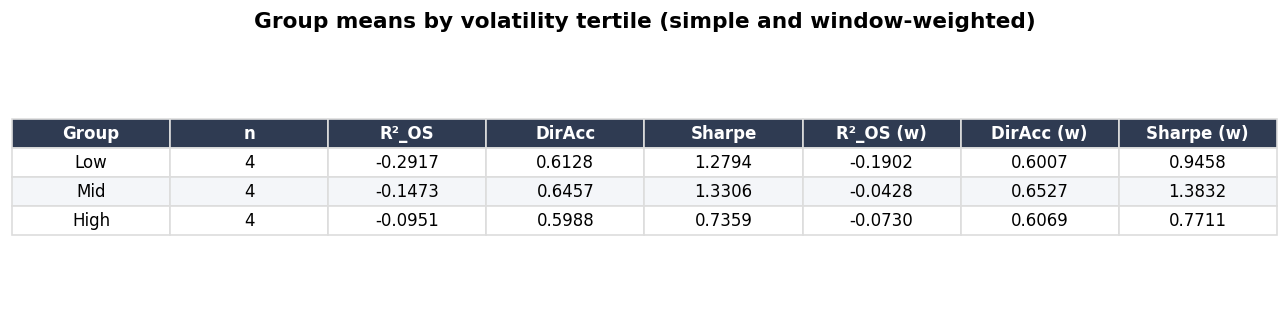

saved: table_group_means.csv + table_group_means.png


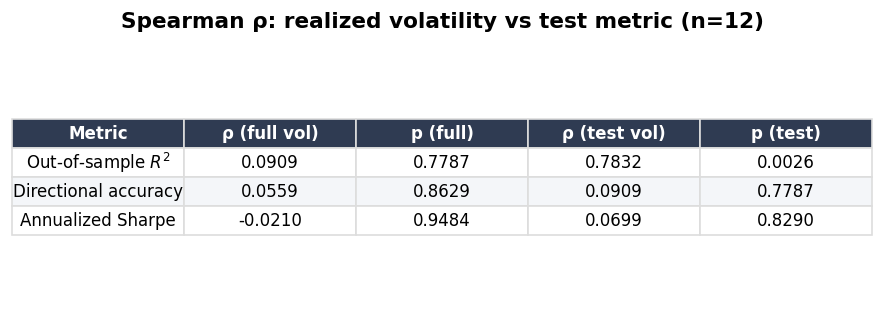

saved: table_spearman.csv + table_spearman.png


,Metric,ρ (full vol),p (full),ρ (test vol),p (test)
0,Out-of-sample $R^2$,0.0909,0.7787,0.7832,0.0026
1,Directional accuracy,0.0559,0.8629,0.0909,0.7787
2,Annualized Sharpe,-0.0210,0.9484,0.0699,0.8290


In [9]:
# --- Table: group means (simple + window-weighted) ---
def wmean(df, key):
    return np.average(df[key].values, weights=df["n_win"].values)

grp_rows = []
for g in GROUPS:
    sub = mg[mg["Group"] == g]
    grp_rows.append([
        g, len(sub),
        sub["r2_oos"].mean(), sub["directional_accuracy"].mean(), sub["sharpe"].mean(),
        wmean(sub, "r2_oos"), wmean(sub, "directional_accuracy"), wmean(sub, "sharpe"),
    ])
grp_cols = ["Group", "n", "R²_OS", "DirAcc", "Sharpe", "R²_OS (w)", "DirAcc (w)", "Sharpe (w)"]
grp = pd.DataFrame(grp_rows, columns=grp_cols)
grp_disp = grp.copy()
for col in grp_cols[2:]:
    grp_disp[col] = grp_disp[col].map(fmt4)
save_table(grp_disp, "table_group_means",
           title="Group means by volatility tertile (simple and window-weighted)")

# --- Table: Spearman rho (vol vs metric, n=12) ---
sp_rows = []
for key, label, _ in METRICS:
    rf, pf = spearmanr(mg["vol_full"], mg[key])
    rt, pt = spearmanr(mg["vol_test"], mg[key])
    sp_rows.append([label, rf, pf, rt, pt])
sp = pd.DataFrame(sp_rows, columns=["Metric", "ρ (full vol)", "p (full)",
                                    "ρ (test vol)", "p (test)"])
sp_disp = sp.copy()
for col in sp.columns[1:]:
    sp_disp[col] = sp_disp[col].map(fmt4)
save_table(sp_disp, "table_spearman",
           title="Spearman ρ: realized volatility vs test metric (n=12)")

In [10]:
import os
print("All deliverables written to", OUTDIR)
for f in sorted(os.listdir(OUTDIR)):
    print("  -", f)

All deliverables written to /Users/christy/Desktop/3/26Spring_MS&E242/MS&E242_final/results/report_plot
  - fig_loss_curve.png
  - fig_market_group_means.png
  - fig_perf_cnn_lstm.png
  - fig_perf_lstm.png
  - fig_perf_lstm_mlp.png
  - table1_raw_data_inventory.csv
  - table1_raw_data_inventory.png
  - table_c_in_vs_out.csv
  - table_c_in_vs_out.png
  - table_group_means.csv
  - table_group_means.png
  - table_spearman.csv
  - table_spearman.png
